<a href="https://colab.research.google.com/github/qiyuriko/ICT304-Tutorial2-YOLO-Weapon-Detection/blob/main/ICT304_Tutorial2_Q3_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q ultralytics kagglehub pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.2 MB/s eta 0:00:00


In [4]:
import os
import yaml
import torch
import kagglehub

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [5]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [6]:
path = kagglehub.dataset_download(
    "kruthisb999/guns-and-knifes-detection-in-cctv-videos"
)

dataset_root = os.path.join(path, "combined_gunsnknifes")

print("Dataset root:", dataset_root)
print("Dataset contents:", os.listdir(dataset_root))

Using Colab cache for faster access to the 'guns-and-knifes-detection-in-cctv-videos' dataset.
Dataset root: /kaggle/input/guns-and-knifes-detection-in-cctv-videos/combined_gunsnknifes
Dataset contents: ['data.yaml', 'val', 'test', 'train']


In [7]:
fixed_yaml_path = "/content/data_fixed.yaml"

fixed_config = {
    "train": os.path.join(dataset_root, "train", "images"),
    "val": os.path.join(dataset_root, "val", "images"),
    "test": os.path.join(dataset_root, "test", "images"),
    "nc": 2,
    "names": ["pistol", "knife"]
}

with open(fixed_yaml_path, "w") as file:
    yaml.dump(fixed_config, file, sort_keys=False)

print("Dataset configuration created successfully.")

Dataset configuration created successfully.


In [8]:
model = YOLO("yolo11n.pt")

print("Pre-trained YOLO model loaded successfully.")

Pre-trained YOLO model loaded successfully.


In [9]:
training_results = model.train(
    data=fixed_yaml_path,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="weapon_detection"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detection, nbs=64, nms=None, opset=None, optimize=False, 

In [10]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/weapon_detection/weights/best.pt")

test_results = best_model.val(
    data="/content/data_fixed.yaml",
    split="test",
    device=0
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 11.3±3.3 MB/s, size: 45.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/guns-and-knifes-detection-in-cctv-videos/combined_gunsnknifes/test/labels... 324 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 324/324 137.4it/s 2.4s
WARNING ⚠️ val: Cache directory /kaggle/input/guns-and-knifes-detection-in-cctv-videos/combined_gunsnknifes/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.3it/s 4.9s
                   all        324        341      0.748      0.539      0.612      0.311
                pistol        182        210      

In [15]:
import os
import matplotlib.pyplot as plt

test_image_dir = os.path.join(dataset_root, "test", "images")

test_images = [
    os.path.join(test_image_dir, file)
    for file in os.listdir(test_image_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

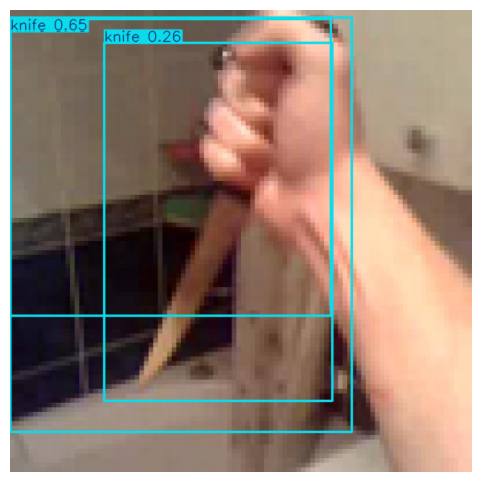

In [16]:
shown = 0

for image_path in test_images:
    results = best_model.predict(
        source=image_path,
        conf=0.25,
        verbose=False
    )

    detected_classes = results[0].boxes.cls.tolist()

    if 1 in detected_classes:  # knife
        plotted_image = results[0].plot()

        plt.figure(figsize=(8, 6))
        plt.imshow(plotted_image[:, :, ::-1])
        plt.axis("off")
        plt.show()

        shown += 1

    if shown == 1:
        break

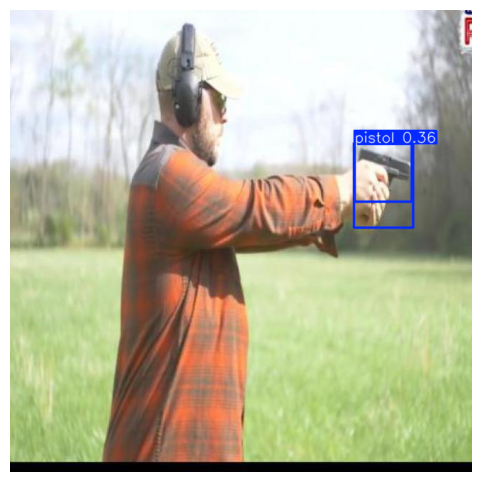

In [17]:
shown = 0

for image_path in test_images:
    results = best_model.predict(
        source=image_path,
        conf=0.25,
        verbose=False
    )

    detected_classes = results[0].boxes.cls.tolist()

    if 0 in detected_classes:  # pistol
        plotted_image = results[0].plot()

        plt.figure(figsize=(8, 6))
        plt.imshow(plotted_image[:, :, ::-1])
        plt.axis("off")
        plt.show()

        shown += 1

    if shown == 1:
        break